In [1]:
import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt
import seaborn as sns

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

import warnings
warnings.filterwarnings('ignore')

In [2]:
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\cheta\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\cheta\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [3]:
df = pd.read_csv("Resume.csv")
print(df.head())

         ID                                         Resume_str  \
0  16852973           HR ADMINISTRATOR/MARKETING ASSOCIATE\...   
1  22323967           HR SPECIALIST, US HR OPERATIONS      ...   
2  33176873           HR DIRECTOR       Summary      Over 2...   
3  27018550           HR SPECIALIST       Summary    Dedica...   
4  17812897           HR MANAGER         Skill Highlights  ...   

                                         Resume_html Category  
0  <div class="fontsize fontface vmargins hmargin...       HR  
1  <div class="fontsize fontface vmargins hmargin...       HR  
2  <div class="fontsize fontface vmargins hmargin...       HR  
3  <div class="fontsize fontface vmargins hmargin...       HR  
4  <div class="fontsize fontface vmargins hmargin...       HR  


In [4]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2484 entries, 0 to 2483
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   ID           2484 non-null   int64 
 1   Resume_str   2484 non-null   object
 2   Resume_html  2484 non-null   object
 3   Category     2484 non-null   object
dtypes: int64(1), object(3)
memory usage: 77.8+ KB
None


In [6]:
df.describe()

,ID
count,2.484000e+03
mean,3.182616e+07
std,2.145735e+07
min,3.547447e+06
25%,1.754430e+07
50%,2.521031e+07
75%,3.611444e+07
max,9.980612e+07


In [7]:
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)
print(df.shape)

(2484, 4)


In [8]:
lemmatizer = WordNetLemmatizer()

stop_words = set(stopwords.words('english'))

def clean_text(text):
    
    text = text.lower()
    
    text = re.sub(r'http\S+', '', text)
    
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    
    words = text.split()
    
    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]
    
    return " ".join(words)

In [9]:
df['cleaned_resume'] = df['Resume_str'].apply(clean_text)

print(df[['Resume_str',
          'cleaned_resume']].head())

                                          Resume_str  \
0           HR ADMINISTRATOR/MARKETING ASSOCIATE\...   
1           HR SPECIALIST, US HR OPERATIONS      ...   
2           HR DIRECTOR       Summary      Over 2...   
3           HR SPECIALIST       Summary    Dedica...   
4           HR MANAGER         Skill Highlights  ...   

                                      cleaned_resume  
0  hr administrator marketing associate hr admini...  
1  hr specialist u hr operation summary versatile...  
2  hr director summary year experience recruiting...  
3  hr specialist summary dedicated driven dynamic...  
4  hr manager skill highlight hr skill hr departm...  


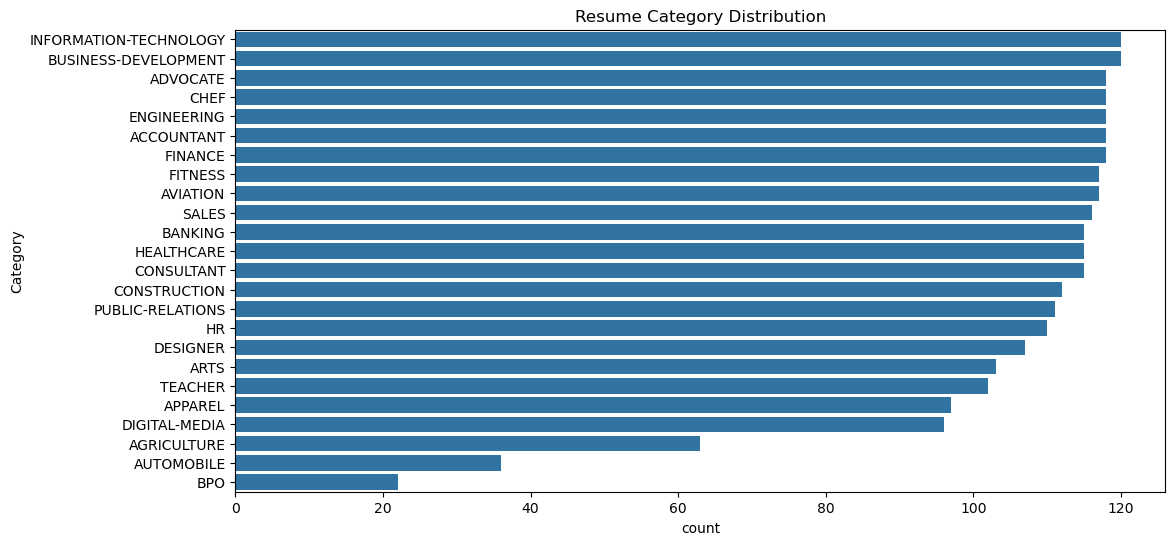

In [10]:
plt.figure(figsize=(12,6))

sns.countplot(
    y=df['Category'],
    order=df['Category'].value_counts().index
)

plt.title("Resume Category Distribution")

plt.show()

In [11]:
skills_list = [
    'python',
    'java',
    'sql',
    'machine learning',
    'deep learning',
    'power bi',
    'tableau',
    'excel',
    'aws',
    'docker',
    'kubernetes',
    'tensorflow',
    'pytorch',
    'communication',
    'leadership',
    'data analysis',
    'nlp',
    'react',
    'node js',
    'mongodb'
]

In [12]:
def extract_skills(text):
    
    text = text.lower()
    
    found_skills = []
    
    for skill in skills_list:
        
        if skill in text:
            found_skills.append(skill)
    
    return found_skills

In [13]:
df['Extracted_Skills'] = df['cleaned_resume'].apply(extract_skills)

print(df[['Category',
          'Extracted_Skills']].head())

  Category             Extracted_Skills
0       HR  [leadership, data analysis]
1       HR              [communication]
2       HR          [excel, leadership]
3       HR       [excel, communication]
4       HR     [excel, aws, leadership]


In [14]:
job_description = """
We are looking for a Data Scientist with skills in Python,
Machine Learning, SQL, Power BI, Deep Learning, and AWS.
Strong communication and analytical skills are required.
"""

In [15]:
cleaned_jd = clean_text(job_description)

In [16]:
tfidf = TfidfVectorizer()

resume_vectors = tfidf.fit_transform(
    df['cleaned_resume']
)

jd_vector = tfidf.transform(
    [cleaned_jd]
)

In [17]:
similarity_scores = cosine_similarity(
    jd_vector,
    resume_vectors
)

In [18]:
df['Match_Score'] = similarity_scores[0] * 100

In [19]:
ranked_candidates = df.sort_values(
    by='Match_Score',
    ascending=False
)

ranked_candidates = ranked_candidates[
    ['Category',
     'Match_Score',
     'Extracted_Skills']
]

print(ranked_candidates.head(10))

                    Category  Match_Score  \
1218              CONSULTANT    16.669940   
1762             ENGINEERING    16.444549   
1303           DIGITAL-MEDIA    16.351120   
2153                 BANKING    15.552152   
298   INFORMATION-TECHNOLOGY    15.292582   
2291                    ARTS    14.996022   
1142              CONSULTANT    14.987339   
929              AGRICULTURE    14.369993   
194                 DESIGNER    13.163745   
331   INFORMATION-TECHNOLOGY    12.750700   

                                       Extracted_Skills  
1218  [python, java, sql, machine learning, data ana...  
1762  [python, sql, machine learning, tableau, excel...  
1303      [python, java, sql, power bi, tableau, excel]  
2153                    [python, sql, machine learning]  
298                        [python, aws, communication]  
2291                                       [leadership]  
1142         [java, sql, tableau, excel, communication]  
929                [python, java, sql, a

In [20]:
required_skills = extract_skills(cleaned_jd)

top_candidate_skills = ranked_candidates.iloc[0]['Extracted_Skills']

missing_skills = list(
    set(required_skills) -
    set(top_candidate_skills)
)

print("Required Skills:")
print(required_skills)

print("\nCandidate Skills:")
print(top_candidate_skills)

print("\nMissing Skills:")
print(missing_skills)

Required Skills:
['python', 'sql', 'machine learning', 'deep learning', 'power bi', 'aws', 'communication']

Candidate Skills:
['python', 'java', 'sql', 'machine learning', 'data analysis']

Missing Skills:
['power bi', 'deep learning', 'communication', 'aws']


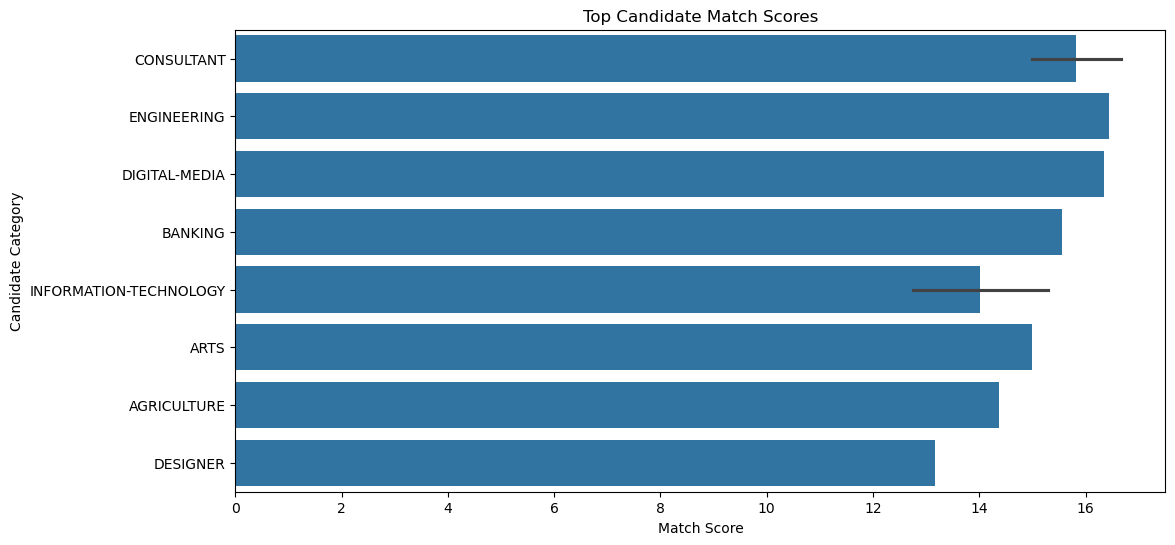

In [21]:
top_candidates = ranked_candidates.head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x='Match_Score',
    y='Category',
    data=top_candidates
)

plt.title("Top Candidate Match Scores")

plt.xlabel("Match Score")

plt.ylabel("Candidate Category")

plt.show()

In [22]:
ranked_candidates.to_csv(
    "candidate_rankings.csv",
    index=False
)

print("Candidate rankings saved successfully!")

Candidate rankings saved successfully!
